In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [ ]:
df.shape

(5000, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.isna().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [ ]:
df[df.duplicated(keep=False)]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
886,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
1870,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [ ]:
df['Physical_Activity_Hours'].value_counts().sort_index(ascending=False)

,count
Physical_Activity_Hours,
4.1,1
3.8,1
3.7,1
3.6,9
3.5,5
3.4,18
3.3,19
3.2,38
3.1,46


# **EDA**

In [ ]:
plt.figure(figsize=(30,30))
def histPlotting(index,col_name):
  plt.subplot(3,2,index)
  sns.histplot(x=df[col_name],kde=True)

<Figure size 3000x3000 with 0 Axes>

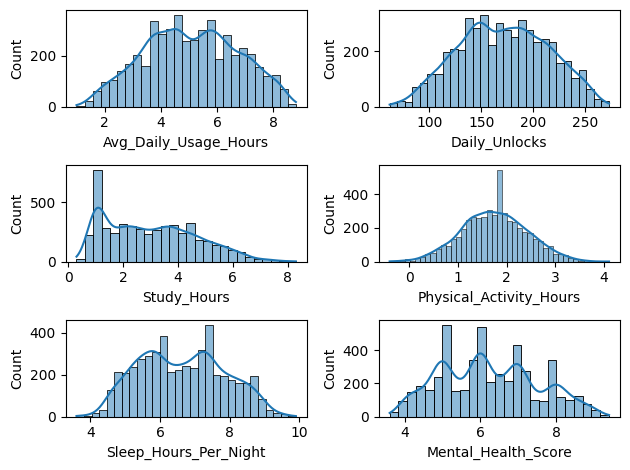

In [ ]:
numeric_cols=['Avg_Daily_Usage_Hours'	,'Daily_Unlocks'	,'Study_Hours'	,'Physical_Activity_Hours'	,'Sleep_Hours_Per_Night'	,'Mental_Health_Score']
for i,col in enumerate(numeric_cols):
  histPlotting(i+1,col)
  plt.tight_layout()

<Axes: >

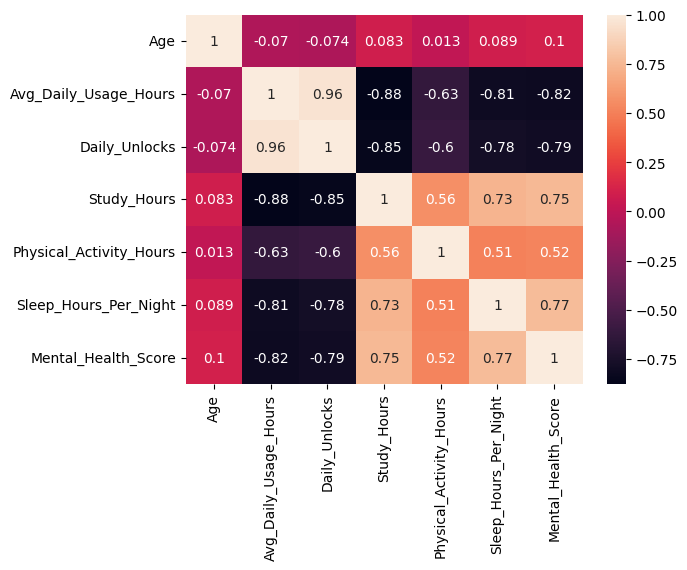

In [ ]:
corr_mat=df.corr(numeric_only=True)
sns.heatmap(data=corr_mat,annot=True)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

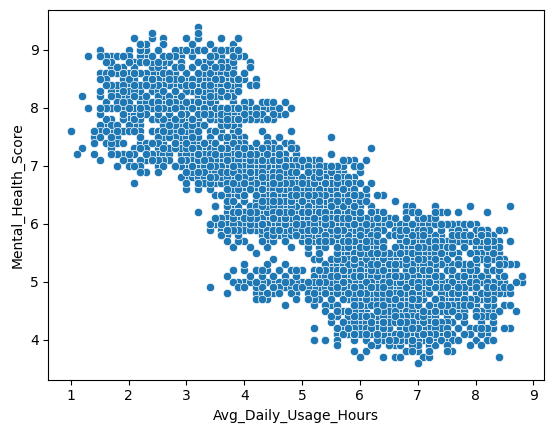

In [ ]:
sns.scatterplot(x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

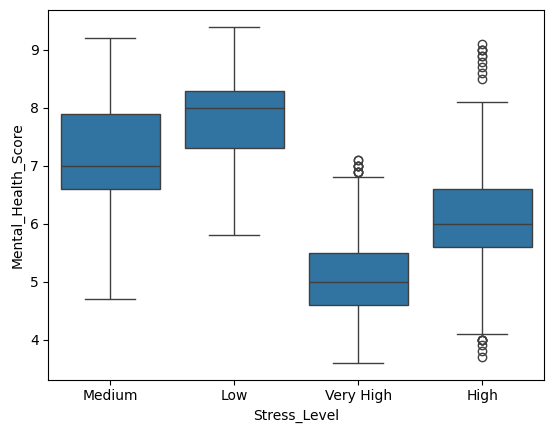

In [ ]:
sns.boxplot(x=df['Stress_Level'],y=df['Mental_Health_Score'])

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

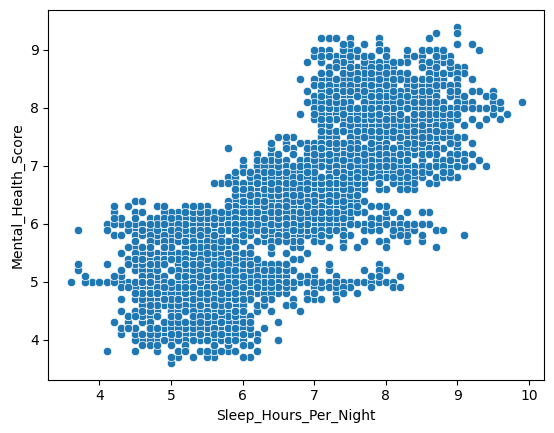

In [ ]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'],y=df['Mental_Health_Score'])

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

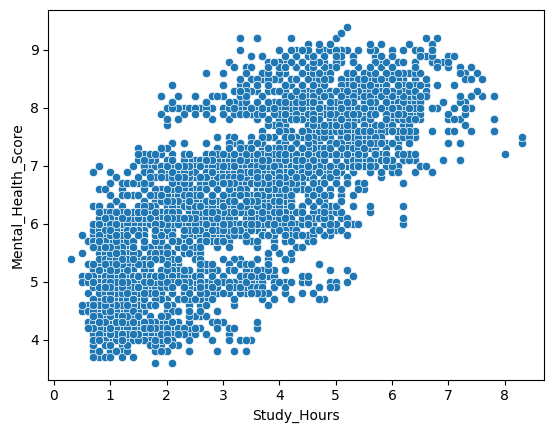

In [ ]:
sns.scatterplot(x=df['Study_Hours'],y=df['Mental_Health_Score'])

<Axes: xlabel='Daily_Unlocks', ylabel='Mental_Health_Score'>

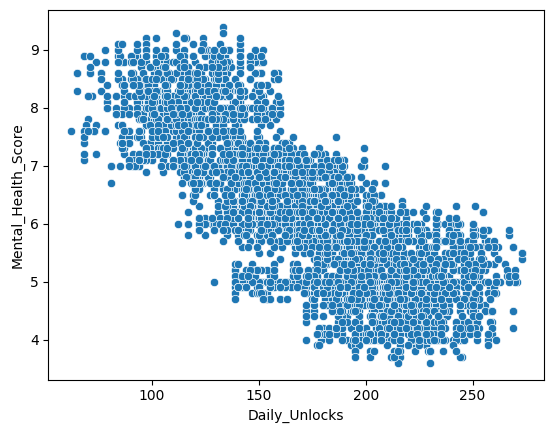

In [ ]:
sns.scatterplot(x=df['Daily_Unlocks'],y=df['Mental_Health_Score'])

<Axes: xlabel='Age', ylabel='count'>

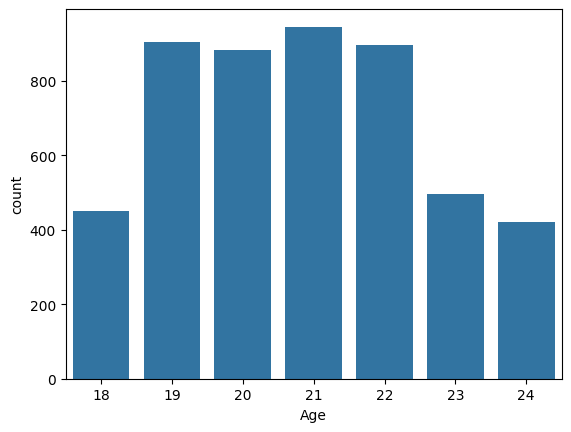

In [ ]:
sns.countplot(x=df['Age'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Instagram'),
  Text(1, 0, 'TikTok'),
  Text(2, 0, 'Facebook'),
  Text(3, 0, 'LinkedIn'),
  Text(4, 0, 'YouTube'),
  Text(5, 0, 'Twitter'),
  Text(6, 0, 'Snapchat'),
  Text(7, 0, 'WhatsApp'),
  Text(8, 0, 'LINE'),
  Text(9, 0, 'VKontakte'),
  Text(10, 0, 'KakaoTalk'),
  Text(11, 0, 'WeChat')])

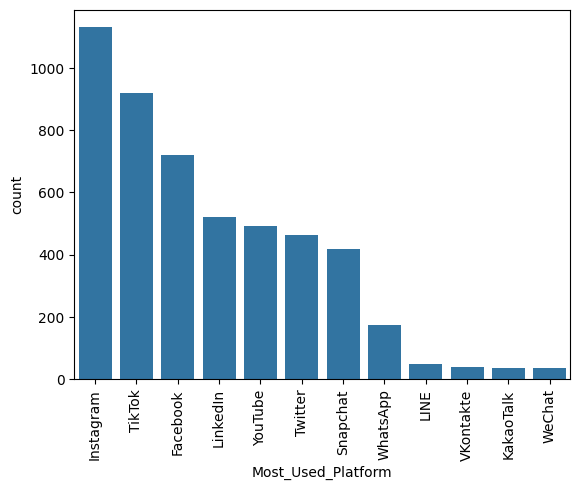

In [ ]:
sns.countplot(x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation='vertical')

<Axes: xlabel='Academic_Level', ylabel='count'>

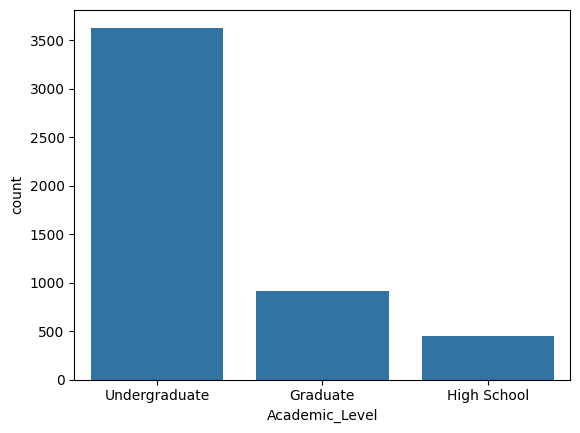

In [ ]:
sns.countplot(x=df['Academic_Level'])

<Axes: xlabel='Gender', ylabel='count'>

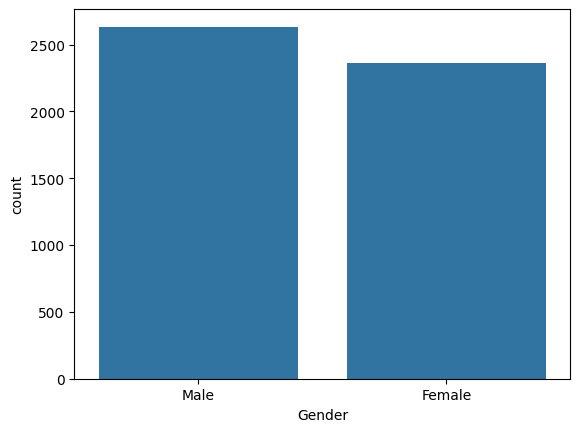

In [ ]:
sns.countplot(x=df['Gender'])

<Axes: xlabel='Purpose_Of_Use', ylabel='count'>

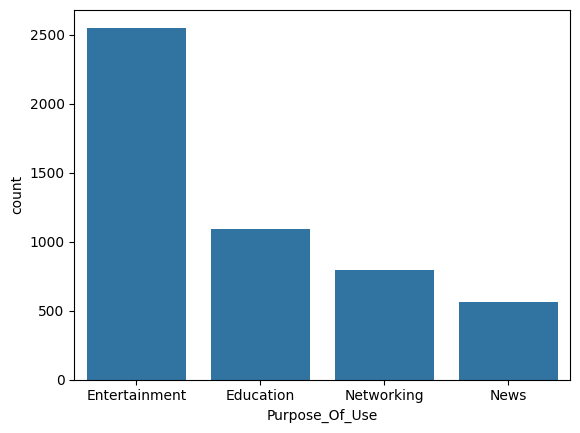

In [ ]:
sns.countplot(x=df['Purpose_Of_Use'],order=df['Purpose_Of_Use'].value_counts().index)

# **Outliers**

In [ ]:
numeric_features=df.select_dtypes(include='number')
Q1=numeric_features.quantile(0.25)
Q3=numeric_features.quantile(0.75)
IQR= Q3-Q1
lower_bound=Q1 - 1.5 * IQR
upper_bound=Q3 + 1.5 * IQR

outliers= (numeric_features<lower_bound) | (numeric_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# **Data Cleaning**

In [ ]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [ ]:
df['Physical_Activity_Hours'].value_counts().sort_index()

,count
Physical_Activity_Hours,
0.0,23
0.1,5
0.2,20
0.3,27
0.4,47
0.5,50
0.6,75
0.7,100
0.8,90


In [ ]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# **Skewness**

In [ ]:
numeric_features.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.040623
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


# **Feature Engineering**

In [ ]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [ ]:
def groupCountry(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [ ]:
df["Grouped_country"]=df['Country'].apply(groupCountry)

In [ ]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [ ]:
from sklearn.model_selection import train_test_split
skewed_col=["Study_Hours"]
other_numeric_cols=['Age','Avg_Daily_Usage_Hours'	,'Daily_Unlocks','Physical_Activity_Hours'	,'Sleep_Hours_Per_Night']
ordinal_col=['Stress_Level']
normal_col=["Gender","Academic_Level","Most_Used_Platform","Purpose_Of_Use","Grouped_country"]

feature_cols=skewed_col+other_numeric_cols+ordinal_col+normal_col

X=df[feature_cols]
y=df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

skewed_pipeline=Pipeline(
    steps=[
        ('log_transform',FunctionTransformer(np.log1p)),
        ('scale',StandardScaler())
    ]
)

other_numeric_cols_pipeline=Pipeline(
    steps=[
        ('scale',StandardScaler())
    ]
)

ordinal_pipeline=Pipeline(
    steps=[
        ('label_encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
    ]
)

normal_col_pipeline=Pipeline(
    steps=[
        ('one_hot_encode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

column_transformer=ColumnTransformer(transformers=[
    ('Skewed_Pipeline',skewed_pipeline,skewed_col),
    ('Other_Numeric_Pipeline',other_numeric_cols_pipeline,other_numeric_cols),
    ('Ordinal_Pipeline',ordinal_pipeline,ordinal_col),
    ('Normal_Col_Pipeline',normal_col_pipeline,normal_col),
])

In [ ]:
column_transformer

ColumnTransformer(transformers=[('Skewed_Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Other_Numeric_Pipeline',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal_Pipeline',
                                 Pipeline(steps=[('label_encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Normal_Col_Pipeline',
                                 Pipeline(steps=[('one_hot_encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Grouped_country'])])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

lr_pipeline=Pipeline(steps=[
    ('preprocessing',column_transformer),
    ('regression_model',LinearRegression())
])

lr_pipeline.fit(X_train,y_train)
lr_pred=lr_pipeline.predict(X_test)
lr_pred_training=lr_pipeline.predict(X_train)

lr_r2_test=r2_score(y_test,lr_pred)
lr_r2_train=r2_score(y_train,lr_pred_training)
print("Accuracy Of Training:",lr_r2_train)
print("Accuracy Of Testing:",lr_r2_test)

lr_mae=mean_absolute_error(y_test,lr_pred)
print("Mean_absolute_error:",lr_mae)

lr_mse=mean_squared_error(y_test,lr_pred)
print("Mean_squared_error:",lr_mae)

Accuracy Of Training: 0.7236771199387538
Accuracy Of Testing: 0.7397944617433021
Mean_absolute_error: 0.5361775634720181
Mean_squared_error: 0.5361775634720181


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

rf_pipeline=Pipeline(steps=[
    ('preprocessing',column_transformer),
('regression_model',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train,y_train)
rf_pred=lr_pipeline.predict(X_test)
rf_pred_training=lr_pipeline.predict(X_train)

rf_r2_test=r2_score(y_test,rf_pred)
rf_r2_train=r2_score(y_train,rf_pred_training)
print("Accuracy Of Training:",rf_r2_train)
print("Accuracy Of Testing:",rf_r2_test)

rf_mae=mean_absolute_error(y_test,rf_pred)
print("Mean_absolute_error:",rf_mae)

rf_mse=mean_squared_error(y_test,rf_pred)
print("Mean_squared_error:",rf_mae)

Accuracy Of Training: 0.9808810505412894
Accuracy Of Testing: 0.8815974517628398
Mean_absolute_error: 0.3420622666666669
Mean_squared_error: 0.3420622666666669


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
params_grid={
    'regression_model__n_estimators':[100,200,300],
    'regression_model__max_depth':[5,10,15],
    'regression_model__min_samples_split':[2,5,10],
    'regression_model__min_samples_leaf':[1,2,4]
}

random_search=RandomizedSearchCV(estimator=rf_pipeline,param_distributions=params_grid,n_iter=15,cv=5,scoring='r2',n_jobs=-1,random_state=42)

random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Other_Numeric_Pipeline',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Un...
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('regression_model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regression_model__max_depth': [5, 10,
                                                                        15],
                                        'regression_model__min_samples_leaf': [1,
                                                                               2,
                                                                               4],
                                        'regression_model__min_samples_split': [2,
                                                                                5,
                                                                                10],
                                        'regression_model__n_estimators': [100,
                                                                           200,
                                                                           300]},
                   random_state=42, scoring='r2')

In [ ]:
random_search.best_params_

{'regression_model__n_estimators': 200,
 'regression_model__min_samples_split': 5,
 'regression_model__min_samples_leaf': 2,
 'regression_model__max_depth': 15}

In [ ]:
rf_best_pipeline=random_search.best_estimator_

rf_best_pred_testing=rf_best_pipeline.predict(X_test)
rf_best_pred_test_r2_score=r2_score(y_test,rf_best_pred_testing)

rf_best_pred_training=rf_best_pipeline.predict(X_train)
rf_best_pred_train_r2_score=r2_score(y_train,rf_best_pred_training)

print('RF Best Score On Training:',rf_best_pred_train_r2_score)

print('RF Best Score On Testing:',rf_best_pred_test_r2_score)

RF Best Score On Training: 0.9547027344112449
RF Best Score On Testing: 0.8650140569761653


In [ ]:
joblib.dump(rf_pipeline,'Mental_health_model.pkl')


['Mental_health_model.pkl']